# 17. Truncating the Tidal Expansion

TidalPy writes the tidal potential as a sum of Kaula (1964) modes. Each mode has an eccentricity function $G_{lpq}(e)$ and an obliquity function $F_{lmp}(I)$, and forces the body at one frequency. The eccentricity functions are infinite series in $e$, so they must be truncated. The eccentricity truncation level sets both the accuracy and the computational cost of every tidal calculation.

Level $N$ keeps every product of two eccentricity functions through $e^N$. The heating, torques, and orbital rates are all quadratic in the potential, so their Taylor series in $e$ are then complete through $e^N$. Level 2 is the classic $e^2$ theory. The tabulated levels are 2, 4, 6, 8, 10 (the default), 20, and 50. Past about $e = 0.57$ no tabulated level holds the heating to 10% for every tide model and spin rate (a synchronous body holds the highest levels to about $e = 0.8$). The `"exact"` option instead computes the eccentricity functions from the exact Kepler orbit, keeping as many modes as its tolerance requires. The obliquity functions use the same scheme, with levels `"off"`, 2, 4, and `"gen"`. The [eccentricity](../../Documentation/Tides/Eccentricity.md) and [obliquity](../../Documentation/Tides/Obliquity.md) documentation pages explain how the levels are built.

This notebook shows when the choice matters: the heating and eccentricity damping rate against eccentricity at each level, the number of modes the exact functions need, the cost of each level, and the helpers that pick a level for you.

In [1]:
%matplotlib inline
import timeit

import numpy as np
import matplotlib.pyplot as plt

from TidalPy.Structures import System, build_world
from TidalPy.Tides.potential import global_potential
from TidalPy.Tides.eccentricity import (ECCENTRICITY_TRUNCATIONS, eccentricity_accuracy_limit,
                                          recommend_eccentricity_truncation)
from TidalPy.Tides.obliquity import obliquity_accuracy_limit, recommend_obliquity_truncation

# Homogeneous Maxwell Io. Its Maxwell time (approx. 2 days) is near the forcing periods, so the Love number
# and each mode's share of the heating depend strongly on frequency.
RADIUS, MASS = 1.8216e6, 8.9319e22
SHEAR, VISCOSITY = 6.0e10, 1.0e16


def maxwell_io(love_method="homogeneous"):
    world = build_world({
        "name": "Io", "type": "terrestrial", "radius_m": RADIUS, "mass_kg": MASS,
        "tides": {"global_tidal_model": "rheology", "love_method": love_method},
        "layers": {"body": {
            "layer_index": 0, "radius_fraction": 1.0, "use_tides": True, "is_static": False,
            "material": {"solid": {
                "eos": {"model": "constant", "reference_density_kg_m3": MASS / (4.0 / 3.0 * np.pi * RADIUS**3),
                        "bulk_modulus_pa": 2.0 * SHEAR},
                "shear_modulus": {"model": "constant", "shear_modulus_pa": SHEAR},
                "shear_viscosity": {"model": "constant", "reference_viscosity_pas": VISCOSITY}}},
            "shear_rheology": {"model": "maxwell"}, "bulk_rheology": {"model": "elastic"}}}})
    world.solve_eos(raise_on_fail=True)
    return world


SYSTEMS = {}   # each Io's system, by id


def jupiter_system(io):
    "Io on its present orbit about Jupiter, spinning synchronously."
    jupiter = build_world({"name": "Jupiter", "type": "gasgiant", "radius_m": 6.9911e7, "mass_kg": 1.898e27,
                           "layers": {"envelope": {"material": "simple_gas", "radius_fraction": 1.0}}})
    system = System("Jupiter-Io")
    system.add_world(jupiter)
    system.add_world(io, tidal_host=jupiter, semi_major_axis=4.217e8, eccentricity=0.0041, synchronous=True)
    SYSTEMS[id(io)] = system
    return system


io = maxwell_io()
system = jupiter_system(io)
N_IO = system.calc_orbital_frequency(io)
M_JUPITER = 1.898e27


def evolution(world, level, eccentricity, exact_tolerance=1.0e-4, obliquity=0.0, obliquity_level=0):
    "Io's heating [W] and de/dt [1/s] at one eccentricity with the given truncations (degree 2)."
    world.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=level,
                          eccentricity_exact_tolerance=exact_tolerance, obliquity_truncation=obliquity_level)
    world.set_obliquity(obliquity)
    SYSTEMS[id(world)].set_eccentricity(world, eccentricity)
    result = SYSTEMS[id(world)].calc_world_evolution(world)
    return result["tidal_heating"], result["de_dt"]


def unique_frequencies(level, eccentricity, exact_tolerance=1.0e-4):
    "The number of distinct forcing frequencies, each of which needs its own Love number solve."
    frequencies = global_potential(RADIUS, N_IO, N_IO, eccentricity, 0.0, 4.217e8, M_JUPITER,
                                   eccentricity_truncation=level, obliquity_truncation=0,
                                   eccentricity_exact_tolerance=exact_tolerance)[2]
    return sum(1 for frequency, _ in frequencies if frequency > 0.0)


print(f"Io orbital period {2.0 * np.pi / N_IO / 86400.0:.3f} d, Maxwell time {VISCOSITY / SHEAR / 86400.0:.2f} d")
print(f"tabulated eccentricity levels: {ECCENTRICITY_TRUNCATIONS}, plus 'exact'")

Io orbital period 1.769 d, Maxwell time 1.93 d
tabulated eccentricity levels: (2, 4, 6, 8, 10, 20, 50), plus 'exact'


## Heating and Eccentricity Damping Against Eccentricity

The reference is the `"exact"` option with a tolerance of $10^{-10}$, so its mode sum is accurate to about $10^{-12}$: the floor that levels 20 and 50 reach in the error panels is the reference's own error. The [Hut 1981 benchmark](../../Benchmarks/Tides/Hut1981_Constant_Time_Lag.ipynb) checks the exact option against a closed form that holds at any eccentricity. Each tabulated level follows the reference until its truncation error sets in. Every level leans low, because a truncated series leaves out positive terms. The eccentricity rate $\dot{e}$ behaves the same way.

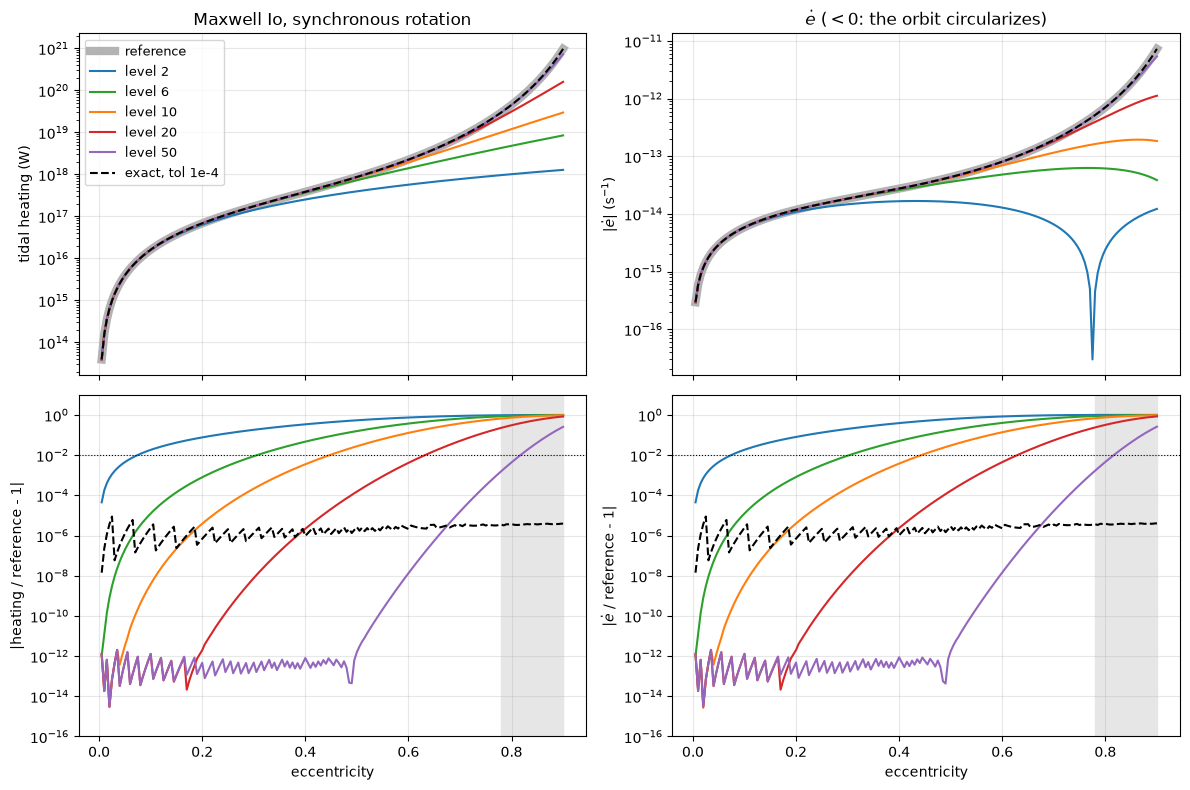

[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.07500000000000001, past 0.075, where its eccentricity truncation (level 2) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in its [tides] table or set_tide_config (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.
[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.27, past 0.265, where its eccentricity truncation (level 6) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in its [tides] table or set_tide_config (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.
[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.4, past 0.395, where its eccentricity truncation (level 10) can misstate the tides by 10% or more (far past it

Largest eccentricity at which each level holds 1% and 1e-6 in heating and in de/dt (and the tabulated worst-case 1% limit):
  level 2           heating: 1% to  0.070, 1e-6 to <0.005;   de/dt: 1% to  0.070, 1e-6 to <0.005;   table: 1% to 0.020
  level 6           heating: 1% to  0.305, 1e-6 to  0.065;   de/dt: 1% to  0.300, 1e-6 to  0.065;   table: 1% to 0.170
  level 10          heating: 1% to  0.445, 1e-6 to  0.170;   de/dt: 1% to  0.440, 1e-6 to  0.170;   table: 1% to 0.290
  level 20          heating: 1% to  0.630, 1e-6 to  0.380;   de/dt: 1% to  0.625, 1e-6 to  0.380;   table: 1% to 0.440
  level 50          heating: 1% to  0.815, 1e-6 to  0.655;   de/dt: 1% to  0.815, 1e-6 to  0.655;   table: 1% to 0.545
  exact (tol 1e-4)  heating: 1% to  0.900, 1e-6 to  0.010;   de/dt: 1% to  0.900, 1e-6 to  0.010
Largest error of 'exact' at its default tolerance: heating 8.8e-06, de/dt 8.8e-06


In [2]:
LEVELS = (2, 6, 10, 20, 50)
COLORS = {2: "tab:blue", 4: "tab:cyan", 6: "tab:green", 8: "tab:olive", 10: "tab:orange", 20: "tab:red",
          50: "tab:purple", "exact": "k"}
eccentricities = np.linspace(0.005, 0.9, 180)

reference = np.array([evolution(io, "exact", e, exact_tolerance=1.0e-10) for e in eccentricities])
results = {level: np.array([evolution(io, level, e) for e in eccentricities]) for level in LEVELS}
results["exact"] = np.array([evolution(io, "exact", e) for e in eccentricities])   # the default tolerance, 1e-4

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for column, (name, unit) in enumerate((("tidal heating", "W"), (r"$|\dot{e}|$", "s$^{-1}$"))):
    ax_value, ax_error = axes[0, column], axes[1, column]
    ax_value.semilogy(eccentricities, np.abs(reference[:, column]), color="0.7", lw=6, label="reference")
    for level, values in results.items():
        label = "exact, tol 1e-4" if level == "exact" else f"level {level}"
        ls = "--" if level == "exact" else "-"
        ax_value.semilogy(eccentricities, np.abs(values[:, column]), color=COLORS[level], ls=ls, label=label)
        error = np.abs(values[:, column] / reference[:, column] - 1.0)
        ax_error.semilogy(eccentricities, np.maximum(error, 1e-16), color=COLORS[level], ls=ls, label=label)
    ax_value.set_ylabel(f"{name} ({unit})")
    ax_error.axhline(1e-2, color="k", lw=0.8, ls=":")
    ax_error.axvspan(0.78, eccentricities[-1], color="0.9", zorder=0)
    ax_error.set_ylim(1e-16, 10.0)
    ax_error.set_ylabel("|heating / reference - 1|" if column == 0 else r"$|\dot{e}$ / reference - 1|")
    ax_error.set_xlabel("eccentricity")
    for ax in (ax_value, ax_error):
        ax.grid(alpha=0.3)
axes[0, 0].set_title("Maxwell Io, synchronous rotation")
axes[0, 1].set_title(r"$\dot{e}$ ($< 0$: the orbit circularizes)")
axes[0, 0].legend(fontsize=9)
plt.tight_layout()
plt.show()


def holds_to(error, tolerance):
    "The largest swept eccentricity up to which the error stays within the tolerance, as text."
    bad = np.flatnonzero(error > tolerance)
    if bad.size == 0:
        return f"{eccentricities[-1]:.3f}"
    if bad[0] == 0:
        return f"<{eccentricities[0]:.3f}"
    return f"{eccentricities[bad[0] - 1]:.3f}"


print("Largest eccentricity at which each level holds 1% and 1e-6 in heating and in de/dt "
      "(and the tabulated worst-case 1% limit):")
for level in LEVELS + ("exact",):
    limits = []
    for column in (0, 1):
        error = np.abs(results[level][:, column] / reference[:, column] - 1.0)
        limits += [holds_to(error, 1e-2), holds_to(error, 1e-6)]
    name = "exact (tol 1e-4)" if level == "exact" else f"level {level}"
    table = "" if level == "exact" else f";   table: 1% to {eccentricity_accuracy_limit(level, 1e-2):.3f}"
    print(f"  {name:17s} heating: 1% to {limits[0]:>6}, 1e-6 to {limits[1]:>6};   "
          f"de/dt: 1% to {limits[2]:>6}, 1e-6 to {limits[3]:>6}{table}")
print(f"Largest error of 'exact' at its default tolerance: heating "
      f"{np.abs(results['exact'][:, 0] / reference[:, 0] - 1).max():.1e}, "
      f"de/dt {np.abs(results['exact'][:, 1] / reference[:, 1] - 1).max():.1e}")

For this synchronous body, each level holds 1% to a higher eccentricity than the limits TidalPy tabulates, which are the worst case over several tide models and spin rates. For example, level 10 (the default) holds to $e \approx 0.44$ here against 0.29 in the table. Level 2 ($e^2$ theory) is already 2% low at $e = 0.1$, and it misses $10^{-6}$ already at the smallest eccentricity swept. Its $\dot{e}$ changes sign just below $e = 0.8$, a truncation artifact pointed out by Renaud et al. (2021) that every higher level removes.

For a synchronous body, past $e \approx 0.78$ (shaded) no tabulated level is reliable. There the highest modes are large terms of opposite sign that nearly cancel, so rounding and any error in the Love numbers are greatly amplified. This body's level 50 still holds 1% to $e \approx 0.82$, but the margin depends on the tide model and the spin: in the worst case level 50 holds 1% only to $e \approx 0.55$. The exact option has no such limit. At its default tolerance of $10^{-4}$ it stays within $10^{-5}$ of the reference at every eccentricity.

## How Many Modes the Exact Functions Need

The exact option keeps the modes $|q| \le Q$, with $Q$ chosen so the weighted squares of the omitted tail fall below its tolerance. The mode count grows quickly with eccentricity, because the eccentricity functions fall off more slowly with $q$ as the orbit approaches a parabola. The left panel shows the active modes of the heating sum. The right panel shows the distinct forcing frequencies, each of which requires a Love number solve. The markers place each tabulated level at the eccentricity where it reaches 1% accuracy (from the measured limits behind `eccentricity_accuracy_limit`).

 level  1% limit e  modes  frequencies  exact modes, tol 1e-2
     2       0.020      4            1                      4
     4       0.095      7            2                     11
     6       0.170     11            3                     15
     8       0.235     15            4                     19
    10       0.290     19            5                     23
    20       0.440     39           10                     43
    50       0.545     99           25                     67


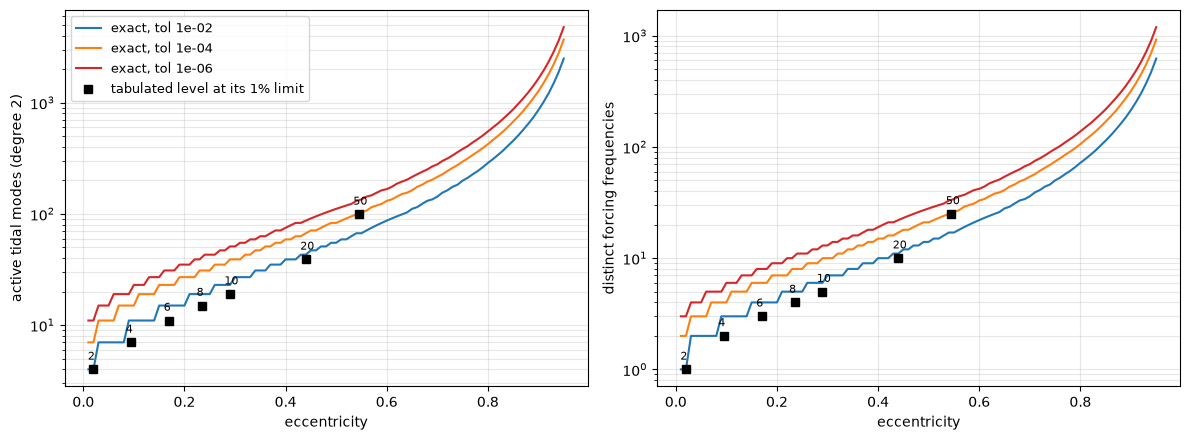

In [3]:
mode_eccentricities = np.linspace(0.01, 0.95, 95)
TOLERANCES = {1e-2: "tab:blue", 1e-4: "tab:orange", 1e-6: "tab:red"}

fig, (ax_modes, ax_frequencies) = plt.subplots(1, 2, figsize=(12, 4.5))
for tolerance, color in TOLERANCES.items():
    modes, frequencies = [], []
    for e in mode_eccentricities:
        evolution(io, "exact", e, exact_tolerance=tolerance)
        modes.append(io.get_num_tidal_modes())
        frequencies.append(unique_frequencies("exact", e, tolerance))
    ax_modes.semilogy(mode_eccentricities, modes, color=color, label=f"exact, tol {tolerance:.0e}")
    ax_frequencies.semilogy(mode_eccentricities, frequencies, color=color, label=f"exact, tol {tolerance:.0e}")

print(f"{'level':>6} {'1% limit e':>11} {'modes':>6} {'frequencies':>12} {'exact modes, tol 1e-2':>22}")
for level in ECCENTRICITY_TRUNCATIONS:
    limit = eccentricity_accuracy_limit(level, 1e-2)
    evolution(io, "exact", limit, exact_tolerance=1e-2)
    exact_modes = io.get_num_tidal_modes()
    evolution(io, level, limit)
    modes, frequencies = io.get_num_tidal_modes(), unique_frequencies(level, limit)
    ax_modes.plot(limit, modes, "ks", ms=6)
    ax_frequencies.plot(limit, frequencies, "ks", ms=6)
    for ax, value in ((ax_modes, modes), (ax_frequencies, frequencies)):
        ax.annotate(str(level), (limit, value), textcoords="offset points", xytext=(-4, 7), fontsize=8)
    print(f"{level:6d} {limit:11.3f} {modes:6d} {frequencies:12d} {exact_modes:22d}")
ax_modes.plot([], [], "ks", label="tabulated level at its 1% limit")
for ax, label in ((ax_modes, "active tidal modes (degree 2)"), (ax_frequencies, "distinct forcing frequencies")):
    ax.set_xlabel("eccentricity")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3, which="both")
ax_modes.legend(fontsize=9)
plt.tight_layout()
plt.show()

A tabulated level carries a fixed set of modes at every eccentricity, while the exact functions keep only what their tolerance requires. At low eccentricity they therefore need fewer modes than a high level. At its own 1% point, each of levels 4 to 20 uses four fewer modes than the exact functions at a 1% tolerance (19 against 23 for level 10), level 2 ties at 4, and level 50 uses more (99 against 67). That tolerance bounds the error of the most demanding tide model, and the actual error is generally far smaller (the $10^{-4}$ curve above stayed within $10^{-5}$). Past the last marker (level 50 at $e \approx 0.55$), the count climbs steeply, to over a thousand modes and several hundred forcing frequencies at $e = 0.9$ for a tolerance of $10^{-4}$.

## What Each Level Costs

Higher levels add modes, and new modes can add distinct forcing frequencies, each needing its own Love number solve. With the homogeneous-sphere Love number used above, a solve is a closed form, so the computational cost is mostly mode bookkeeping. With the radial solver, each distinct frequency is a full radial integration, so the frequency count sets the cost. Both are timed below at $e = 0.1$ for the tabulated levels, and across eccentricity for the exact option.

truncation     e  modes  freqs  heating error  homogeneous  radial solver
         2  0.10      4      1        1.8e-02       7.7 us        0.40 ms


         4  0.10      7      2        6.3e-04       8.3 us        0.63 ms
         6  0.10     11      3        1.2e-05       8.6 us        0.63 ms
         8  0.10     15      4        2.3e-07       9.2 us        0.69 ms
        10  0.10     19      5        3.8e-09       9.6 us        0.78 ms
        20  0.10     39     10        1.3e-12      11.8 us        1.07 ms
        50  0.10     99     25        1.3e-12      21.2 us        2.58 ms


     exact  0.10     15      4        2.4e-06      24.4 us        0.74 ms


     exact  0.30     39     10        1.4e-06      43.1 us        1.19 ms
     exact  0.50     83     21        2.6e-06      86.3 us        1.90 ms


     exact  0.70    215     54        3.3e-06     171.3 us        4.56 ms


     exact  0.90   1271    318        3.9e-06    1608.1 us       28.18 ms


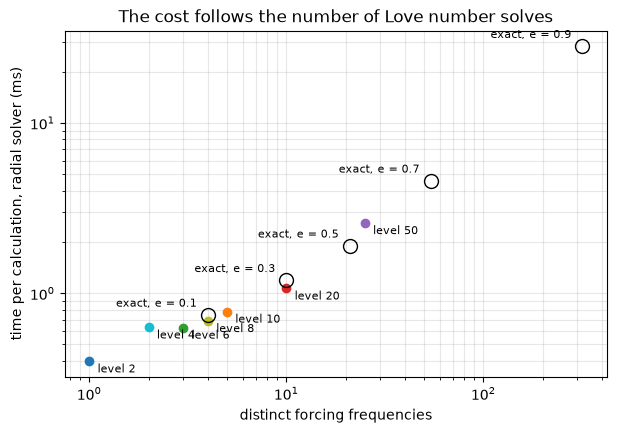

[TidalPy] [warning] TidalPy: global_potential has an eccentricity of 0.1, past 0.075, where its eccentricity truncation (level 2) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in the eccentricity_truncation and obliquity_truncation arguments (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.
[TidalPy] [warning] TidalPy: world 'Io' has an eccentricity of 0.1, past 0.075, where its eccentricity truncation (level 2) can misstate the tides by 10% or more (far past it, the heating can come out negative). Raise the eccentricity truncation in its [tides] table or set_tide_config (recommend_eccentricity_truncation picks a level for a tolerance); past about 0.57 use 'exact'. Shown once per level.


In [4]:
def time_per_call(world, level, eccentricity, number):
    "Seconds per heating calculation (best of five batches)."
    evolution(world, level, eccentricity)
    calc = SYSTEMS[id(world)].calc_world_evolution
    return min(timeit.repeat(lambda: calc(world), number=number, repeat=5)) / number


# Same body with the radial solver Love method, in its own system
io_radial = maxwell_io("radial_solver")
jupiter_system(io_radial)

rows = [(level, 0.1) for level in ECCENTRICITY_TRUNCATIONS] + [("exact", e) for e in (0.1, 0.3, 0.5, 0.7, 0.9)]
print(f"{'truncation':>10} {'e':>5} {'modes':>6} {'freqs':>6} {'heating error':>14} "
      f"{'homogeneous':>12} {'radial solver':>14}")
timings = []
for level, e in rows:
    reference_heating = evolution(io, "exact", e, exact_tolerance=1.0e-10)[0]
    heating = evolution(io, level, e)[0]
    modes, frequencies = io.get_num_tidal_modes(), unique_frequencies(level, e)
    homogeneous = time_per_call(io, level, e, 200)
    radial = time_per_call(io_radial, level, e, 3)
    timings.append((level, e, frequencies, homogeneous, radial))
    print(f"{str(level):>10} {e:5.2f} {modes:6d} {frequencies:6d} {abs(heating / reference_heating - 1):14.1e} "
          f"{homogeneous * 1e6:9.1f} us {radial * 1e3:11.2f} ms")

fig, ax = plt.subplots(figsize=(7, 4.5))
for level, e, frequencies, homogeneous, radial in timings:
    color = "k" if level == "exact" else COLORS.get(level, "tab:gray")
    ax.loglog(frequencies, radial * 1e3, "o", color=color, ms=10 if level == "exact" else 6,
              mfc="none" if level == "exact" else color)
    ax.annotate(f"exact, e = {e}" if level == "exact" else f"level {level}", (frequencies, radial * 1e3),
                textcoords="offset points", xytext=(-8, 6) if level == "exact" else (6, -8), fontsize=8,
                ha="right" if level == "exact" else "left")
ax.set_xlabel("distinct forcing frequencies")
ax.set_ylabel("time per calculation, radial solver (ms)")
ax.set_title("The cost follows the number of Love number solves")
ax.grid(alpha=0.3, which="both")
plt.show()

With a closed-form Love number the tabulated levels are cheap, and even the exact option at $e = 0.9$ costs only a millisecond or two. With the radial solver the cost grows with the number of distinct frequencies: from under a millisecond at level 2, to a few milliseconds at level 50, to a few tens of milliseconds for the exact functions at $e = 0.9$. The timings depend on the machine and its load. Levels 20 and 50 show the same heating error at $e = 0.1$, about $10^{-12}$, which is the reference's own error. A level far above what the eccentricity needs is paid for in every call. In a long orbital integration, where a resonance can drive the eccentricity up, a low level is fast but loses accuracy as $e$ rises. A world's `calc_tides` logs a warning, once per world, when the eccentricity passes the point where its level can be 10% low.

## Choosing a Level

`recommend_eccentricity_truncation(eccentricity, tolerance, max_degree_l)` returns the lowest tabulated level that holds a heating tolerance at a given eccentricity, or `"exact"` when none does. Its limits were measured over constant-phase-lag, constant-time-lag, Maxwell, and Andrade tides at spin rates from -10 to 30 times the mean motion, so they are a worst case: a synchronous or slowly rotating body usually holds a level further. Harmonic degrees $l \ge 3$ lose accuracy at a lower eccentricity than degree 2, so pass `max_degree_l` when a solve includes them.

In [5]:
print(f"{'e':>5} {'1%, l = 2':>10} {'1%, l = 3':>10} {'1e-4, l = 2':>12} {'1e-6, l = 2':>12}")
for e in (0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
    print(f"{e:5.3f} {str(recommend_eccentricity_truncation(e)):>10} "
          f"{str(recommend_eccentricity_truncation(e, max_degree_l=3)):>10} "
          f"{str(recommend_eccentricity_truncation(e, tolerance=1e-4)):>12} "
          f"{str(recommend_eccentricity_truncation(e, tolerance=1e-6)):>12}")

    e  1%, l = 2  1%, l = 3  1e-4, l = 2  1e-6, l = 2
0.001          2          2            2            4
0.010          2          2            4            6
0.050          4          4            6            8
0.100          6          6            8           10
0.200          8         10           20           20
0.300         20         20           20           50
0.400         20         50           50           50
0.500         50         50        exact        exact
0.600      exact      exact        exact        exact
0.700      exact      exact        exact        exact
0.800      exact      exact        exact        exact
0.900      exact      exact        exact        exact


## Obliquity Levels

The obliquity functions follow the same rule: level $N$ keeps every product of two of them through $I^N$. Unlike the eccentricity series, they converge at every obliquity. The general functions (`"gen"`) are exact and barely more expensive, so the truncated levels exist only to drop modes at small obliquity. Level `"off"` ignores the obliquity entirely. The sweep below tilts the synchronous Io at a small eccentricity, where the obliquity tide dominates. Far past a level's range, its truncated sum can turn negative. Here level 4 does so past about 65 degrees, where its heating drops off the logarithmic axis.

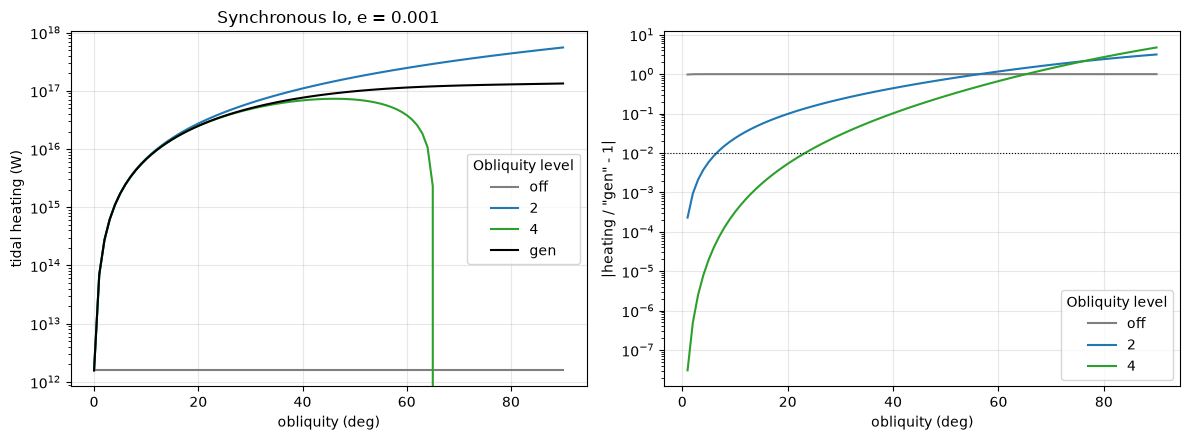

[TidalPy] [warning] TidalPy: world 'Io' has an obliquity of 1.745e-02 rad but its obliquity truncation is off, so its obliquity tides are ignored. Set the obliquity truncation (2, 4, or 'gen') in its [tides] table or set_tide_config to include them. Shown once.
[TidalPy] [warning] TidalPy: world 'Io' has an obliquity of 0.3665 rad, past 0.35, where its obliquity truncation (level 2) can misstate the tides by 10% or more. Raise the obliquity truncation in its [tides] table or set_tide_config (recommend_obliquity_truncation picks a level for a tolerance), or use 'gen'. Shown once per level.
[TidalPy] [warning] TidalPy: world 'Io' has an obliquity of 0.6981 rad, past 0.695, where its obliquity truncation (level 4) can misstate the tides by 10% or more. Raise the obliquity truncation in its [tides] table or set_tide_config (recommend_obliquity_truncation picks a level for a tolerance), or use 'gen'. Shown once per level.


tabulated 1% limits: level 2 to 6.3 deg, level 4 to 23.2 deg
I =  1.0 deg: recommend_obliquity_truncation -> 2 (1%), 4 (1e-4)
I =  5.0 deg: recommend_obliquity_truncation -> 2 (1%), 4 (1e-4)
I = 10.0 deg: recommend_obliquity_truncation -> 4 (1%), 'gen' (1e-4)
I = 23.4 deg: recommend_obliquity_truncation -> 'gen' (1%), 'gen' (1e-4)
I = 45.0 deg: recommend_obliquity_truncation -> 'gen' (1%), 'gen' (1e-4)


In [6]:
obliquities = np.radians(np.linspace(0.0, 90.0, 91))
OBLIQUITY_LEVELS = {"off": "tab:gray", 2: "tab:blue", 4: "tab:green", "gen": "k"}
obliquity_heating = {level: np.array([evolution(io, 10, 0.001, obliquity=inc, obliquity_level=level)[0]
                                      for inc in obliquities]) for level in OBLIQUITY_LEVELS}
io.set_obliquity(0.0)

fig, (ax, ax_error) = plt.subplots(1, 2, figsize=(12, 4.5))
for level, color in OBLIQUITY_LEVELS.items():
    ax.semilogy(np.degrees(obliquities), obliquity_heating[level], color=color, label=f"{level}")
    if level != "gen":
        error = np.abs(obliquity_heating[level][1:] / obliquity_heating["gen"][1:] - 1.0)
        ax_error.semilogy(np.degrees(obliquities[1:]), np.maximum(error, 1e-16), color=color, label=f"{level}")
ax_error.axhline(1e-2, color="k", lw=0.8, ls=":")
ax.set_ylabel("tidal heating (W)")
ax_error.set_ylabel('|heating / "gen" - 1|')
ax.set_title("Synchronous Io, e = 0.001")
for axis in (ax, ax_error):
    axis.set_xlabel("obliquity (deg)")
    axis.grid(alpha=0.3)
    axis.legend(title="Obliquity level")
plt.tight_layout()
plt.show()

print(f"tabulated 1% limits: level 2 to {np.degrees(obliquity_accuracy_limit(2, 1e-2)):.1f} deg, "
      f"level 4 to {np.degrees(obliquity_accuracy_limit(4, 1e-2)):.1f} deg")
for degrees in (1.0, 5.0, 10.0, 23.4, 45.0):
    print(f"I = {degrees:4.1f} deg: recommend_obliquity_truncation -> "
          f"{recommend_obliquity_truncation(np.radians(degrees))!r} (1%), "
          f"{recommend_obliquity_truncation(np.radians(degrees), tolerance=1e-4)!r} (1e-4)")

## Summary

- Eccentricity level $N$ keeps every term of the heating and orbital rates through $e^N$. Every level leans low, and a higher level is never less accurate.
- The default, level 10, is good to about 1% up to $e \approx 0.29$ in the worst case (0.44 for this synchronous Io). Level 20 reaches about 0.44 and level 50 about 0.55 (this Io holds level 50 to about 0.8). Past that, use `"exact"`, whose tolerance bounds the heating error at any eccentricity below 1.
- The computational cost of a level is set by its number of distinct forcing frequencies, each a Love number solve. With the radial solver, use the lowest level that holds your tolerance over the expected eccentricities, and let `recommend_eccentricity_truncation` pick it.
- The obliquity levels work the same way in $I$. Level 2 is good to about 6 degrees and level 4 to about 23. Past that, `"gen"` is exact and cheap.